<a href="https://colab.research.google.com/github/td0309/td/blob/main/project3code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stroke Prediction Dataset**

Theo Tổ chức Y tế Thế giới (WHO), đột quỵ là nguyên nhân gây tử vong đứng hàng thứ hai trên toàn cầu, chiếm khoảng 11% tổng số ca tử vong.
Bộ dữ liệu này được sử dụng để dự đoán nguy cơ đột quỵ của bệnh nhân dựa trên các thông số đầu vào như giới tính, độ tuổi, các bệnh lý nền và tình trạng hút thuốc. Mỗi dòng dữ liệu cung cấp các thông tin liên quan về bệnh nhân.

## **1. Giới thiệu về dataset sẽ sử dụng để dự đoán**

Dataset dược lấy từ Kaggle (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data). Dataset này bao gồm 5.110 điểm dữ liệu,
gồm 12 thuộc tính: 10 biến độc lập đóng vai trò là các đặc trưng và một biến phụ thuộc đóng vai trò là nhãn lớp.

Giải thích thuộc tính

1. id: mã định danh bệnh nhân
2. gender: "Male", "Female" or "Other"
3. age: tuổi của bệnh nhân
4. hypertension: 0 nếu bệnh nhân không bị tăng huyết áp, 1 nếu bệnh nhân bị tăng huyết áp
5. heart_disease: 0 nếu bệnh nhân không mắc bệnh tim, 1 nếu bệnh nhân mắc bệnh tim
6. ever_married: "No" or "Yes"
7. work_type: "children", "Govt_jov", "Never_worked", "Private" hoặc "Self-employed"
8. Residence_type: "Rural" or "Urban"
9. avg_glucose_level: mức đường huyết trung bình
10. bmi: chỉ số khối cơ thể
11. smoking_status: "formerly smoked", "never smoked", "smokes" hoặc "Unknown"*
12. stroke: 1 là bệnh nhân có bị đột quỵ và 0 là không bị.


*Ghi chú: Unknown ở trong cột smoking_status có nghĩa là thông tin đó không có sẵn cho bệnh nhân này*

## **I. Khai báo thư viện**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc, RocCurveDisplay
)

## **II. Đọc data - EDA**

In [ ]:
df = pd.read_csv("stroke.csv")
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1116,65453,Female,56.0,1,0,Yes,Govt_job,Urban,82.44,27.8,smokes,0
555,37629,Female,55.0,0,0,No,Private,Rural,93.36,28.4,never smoked,0
3079,575,Male,13.0,0,0,No,children,Rural,98.65,20.1,Unknown,0
4109,9912,Male,39.0,0,0,Yes,Private,Rural,109.19,29.8,Unknown,0
2027,31689,Female,58.0,0,0,Yes,Private,Rural,107.17,27.7,Unknown,0


Phần trăm missing values:
bmi                  3.933464
id                   0.000000
age                  0.000000
gender               0.000000
hypertension         0.000000
heart_disease        0.000000
work_type            0.000000
ever_married         0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
smoking_status       0.000000
stroke               0.000000
dtype: float64


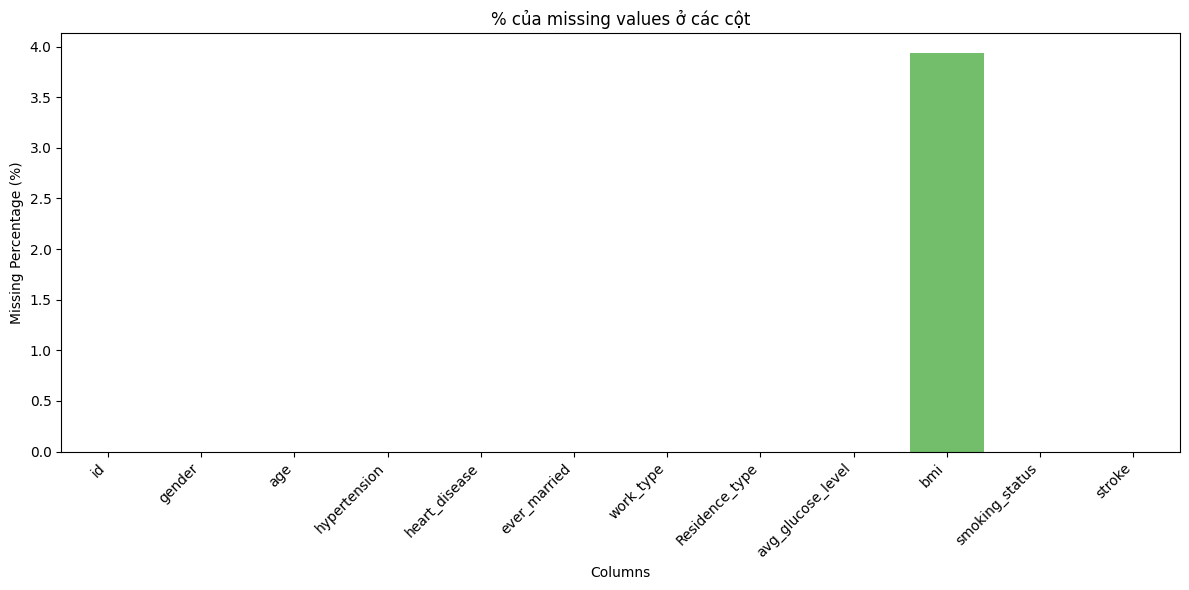

In [ ]:
# Tính % missing
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Phần trăm missing values:")
print(missing_percent.sort_values(ascending=False))
# Visualize missing percentages with a bar chart for clearer understanding
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='viridis')
plt.title('% của missing values ở các cột')
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Dataset này có values hầu như đầy đủ, chỉ có mỗi cột bmi thiếu chưa tới 4% cho nên chúng ta sẽ thay thế các giá trị bị thiếu này bằng median

In [ ]:
#Thay missing values = median
columns_with_missing_values = df.columns[df.isnull().any()].tolist()

for col in columns_with_missing_values:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

print("Missing values after median imputation:")
print(df.isnull().sum())

df.info()

Missing values after median imputation:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-nul

In [ ]:
# Kiểm tra duplicates
print("\nSố lượng duplicates:", df.duplicated().sum())


Số lượng duplicates: 0


In [ ]:
#Lấy tên các cột có kiểu dữ liệu liên tục
#Tự động lấy các cột numerical
numerical_cols = df.select_dtypes(include=['float64']).columns.tolist()

# Tự động phân loại continuous: unique values > 4
continuous_cols = [col for col in numerical_cols if df[col].nunique() > 4]

# In kết quả
print(f"Các cột liên tục: {continuous_cols}")
print(f"Số lượng: {len(continuous_cols)}")

Các cột liên tục: ['age', 'avg_glucose_level', 'bmi']
Số lượng: 3


In [ ]:
for col in df.select_dtypes(include='number').columns:
    if (df[col] < 0).any():
        print(f"{col}: CÓ giá trị âm (tổng: {(df[col] < 0).sum()})")
    else:
        print(f"{col}: Không có giá trị âm")

id: Không có giá trị âm
age: Không có giá trị âm
hypertension: Không có giá trị âm
heart_disease: Không có giá trị âm
avg_glucose_level: Không có giá trị âm
bmi: Không có giá trị âm
stroke: Không có giá trị âm



=== age ===
Q1: 25.00 | Q3: 61.00 | IQR: 36.00
Giới hạn: [-29.00, 115.00]
Số outliers: 0

=== avg_glucose_level ===
Q1: 77.25 | Q3: 114.09 | IQR: 36.84
Giới hạn: [21.98, 169.36]
Số outliers: 627
Một số giá trị outlier mẫu: [228.69, 202.21, 171.23, 174.12, 186.21]

=== bmi ===
Q1: 23.80 | Q3: 32.80 | IQR: 9.00
Giới hạn: [10.30, 46.30]
Số outliers: 126
Một số giá trị outlier mẫu: [48.9, 47.5, 56.6, 50.1, 54.6]


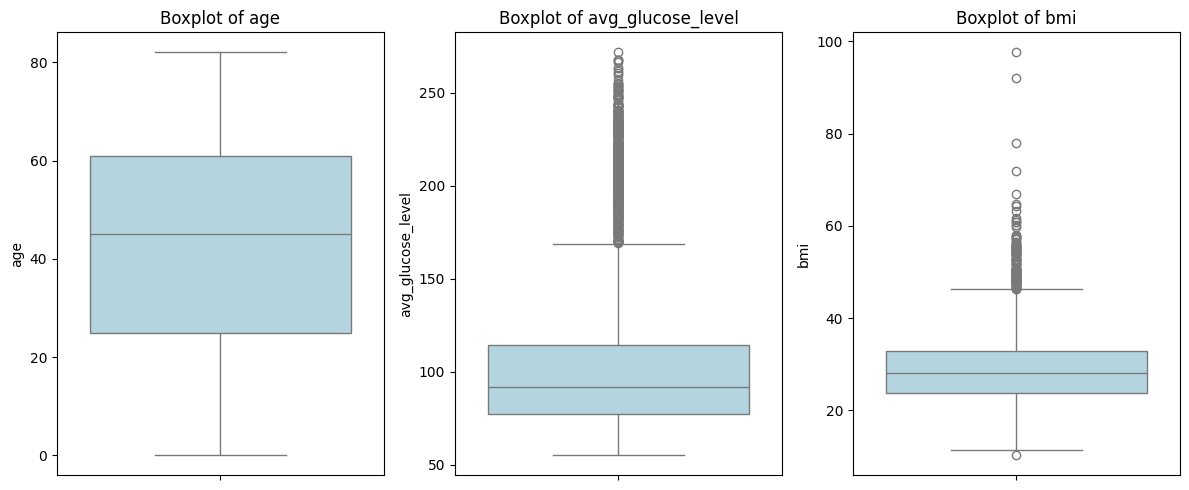

In [ ]:
def detect_outliers_iqr(df, col):
    series = df[col].dropna()  # bỏ NaN cho bmi
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    print(f"\n=== {col} ===")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Giới hạn: [{lower:.2f}, {upper:.2f}]")
    print(f"Số outliers: {len(outliers)}")
    if len(outliers) > 0:
        print("Một số giá trị outlier mẫu:", outliers.head().tolist())
    return outliers

# Chạy cho từng cột
for col in numerical_cols:
    detect_outliers_iqr(df, col)

# Boxplot cho các cột số
plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

3 boxplot cho age, avg_glucose_level, bmi. Cho thấy age không có outlier, avg_glucose_level có nhiều điểm bất thường lệch cao (627 outliers), bmi cũng có một số giá trị cao bất thường (126 outliers) — phản ánh vài bệnh nhân có đường huyết/BMI cao vượt trội so với phần lớn dữ liệu.


In [ ]:
def show_outliers(df, col, n=3):
    s = df[col].dropna()
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    low_out = s[s < lower].nsmallest(n)
    up_out  = s[s > upper].nlargest(n)

    print(f"\n{col}:")
    print(f"  Lower bound = {lower:.2f} → mẫu: {list(low_out)}")
    print(f"  Upper bound = {upper:.2f} → mẫu: {list(up_out)}")

# Ví dụ dùng (thay df và cột của bạn)
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
for col in numeric_cols:
    show_outliers(df, col, n=4)   # hiện 4 mẫu mỗi bên


age:
  Lower bound = -29.00 → mẫu: []
  Upper bound = 115.00 → mẫu: []

avg_glucose_level:
  Lower bound = 21.98 → mẫu: []
  Upper bound = 169.36 → mẫu: [271.74, 267.76, 267.61, 267.6]

bmi:
  Lower bound = 10.30 → mẫu: [10.3]
  Upper bound = 46.30 → mẫu: [97.6, 92.0, 78.0, 71.9]


In [ ]:
# Danh sách cột phân loại cần kiểm tra
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

print("=== Kiểm tra giá trị duy nhất (unique) trong từng cột phân loại ===")
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\n{col}: {len(unique_vals)} giá trị duy nhất")
    print(sorted(unique_vals))  # Sắp xếp để dễ thấy inconsistency

# Kiểm tra thêm nếu có giá trị lạ (ví dụ: chữ hoa/thường, lỗi viết)
print("\n=== Kiểm tra thêm inconsistency (ví dụ: 'yes' vs 'Yes') ===")
for col in cat_cols:
    # Chuyển về chữ thường để kiểm tra
    lower_unique = df[col].astype(str).str.lower().unique()
    if len(lower_unique) < len(df[col].unique()):
        print(f"{col} có giá trị tương đương nhưng khác chữ hoa/thường!")

# Kiểm tra bmi (nên là số hoặc NaN)
print("\n=== Kiểm tra bmi ===")
print("Kiểu dữ liệu:", df['bmi'].dtype)
print("Số NaN:", df['bmi'].isnull().sum())
print("Giá trị lạ (nếu có):", df['bmi'].unique()[:10])  # Xem 10 giá trị đầu

# Nếu muốn sửa nhanh (ví dụ: chuyển ever_married về Yes/No)
# df['ever_married'] = df['ever_married'].map({1: 'Yes', 0: 'No', 'Yes': 'Yes', 'No': 'No'})

=== Kiểm tra giá trị duy nhất (unique) trong từng cột phân loại ===

gender: 3 giá trị duy nhất
['Female', 'Male', 'Other']

ever_married: 2 giá trị duy nhất
['No', 'Yes']

work_type: 5 giá trị duy nhất
['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']

Residence_type: 2 giá trị duy nhất
['Rural', 'Urban']

smoking_status: 4 giá trị duy nhất
['Unknown', 'formerly smoked', 'never smoked', 'smokes']

=== Kiểm tra thêm inconsistency (ví dụ: 'yes' vs 'Yes') ===

=== Kiểm tra bmi ===
Kiểu dữ liệu: float64
Số NaN: 0
Giá trị lạ (nếu có): [36.6 28.1 32.5 34.4 24.  29.  27.4 22.8 24.2 29.7]


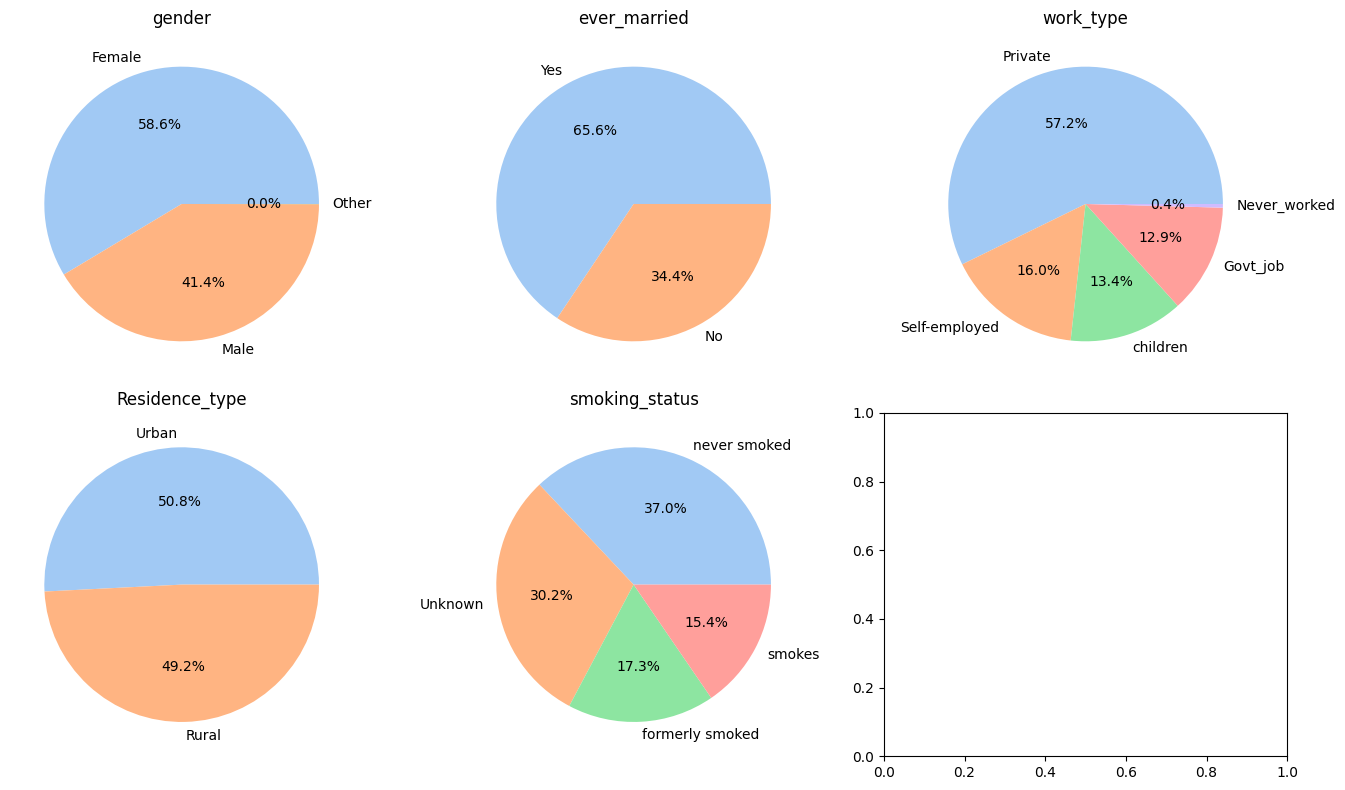

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[i], title=col, colors=sns.color_palette('pastel'))
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Tỷ lệ phần trăm các nhóm trong từng biến phân loại: gender (chủ yếu Nữ), ever_married, work_type (phần lớn Private), Residence_type (Urban/Rural gần bằng nhau), smoking_status. Giúp thấy nhanh cơ cấu dữ liệu, phát hiện lớp thiểu số (như "Other" trong gender, "Never_worked" trong work_type).

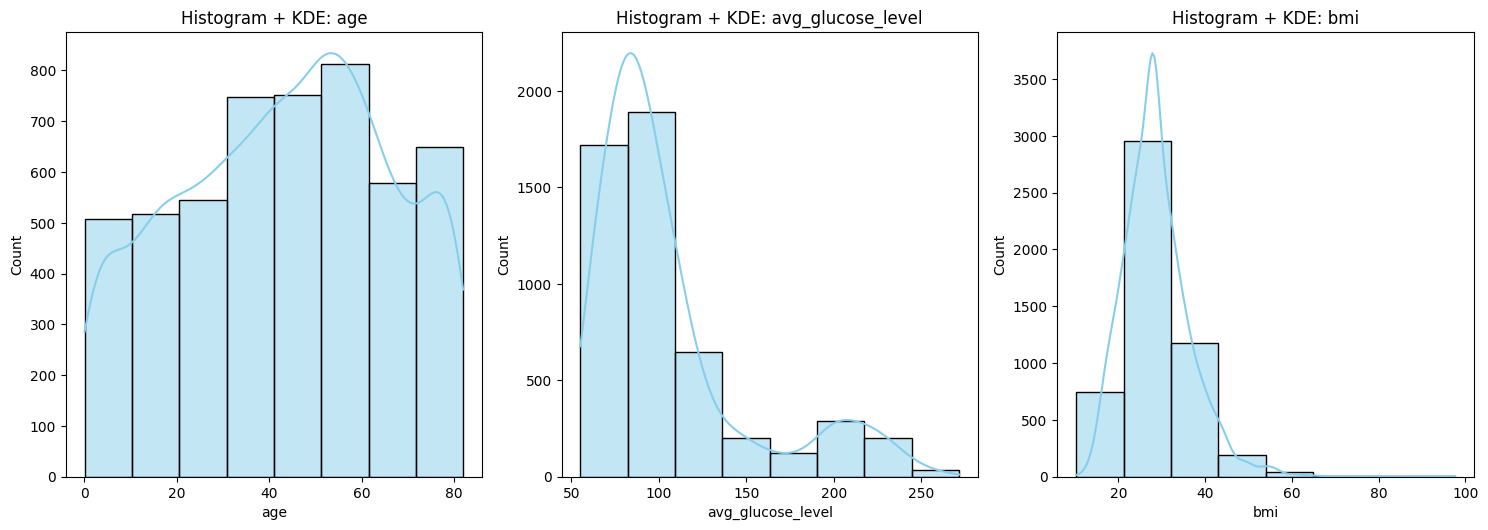

In [ ]:
fig = plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    # Histogram + KDE
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=8, color='skyblue')
    plt.title(f'Histogram + KDE: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')


plt.tight_layout()
plt.show()

3 biểu đồ phân phối cho age, avg_glucose_level, bmi. age phân phối khá đều/rộng; avg_glucose_level lệch phải (right-skewed) với đuôi dài về giá trị cao; bmi gần chuẩn nhưng cũng hơi lệch phải.

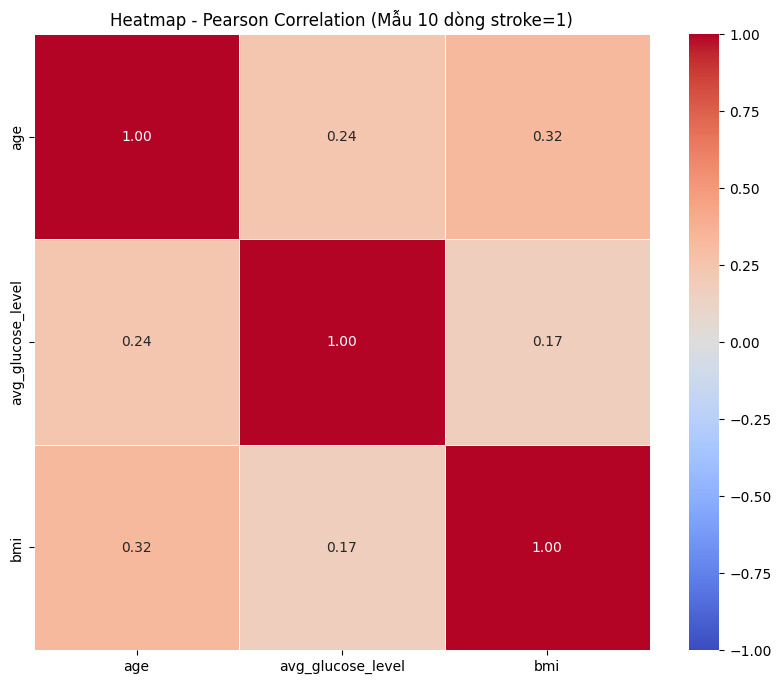

In [ ]:
# Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(method='pearson'),
            annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Heatmap - Pearson Correlation (Mẫu 10 dòng stroke=1)')
plt.show()

Ma trận tương quan tuyến tính giữa 3 biến số liên tục. Tương quan giữa các biến này với nhau và với stroke đều khá yếu (Pearson chỉ bắt được quan hệ tuyến tính).

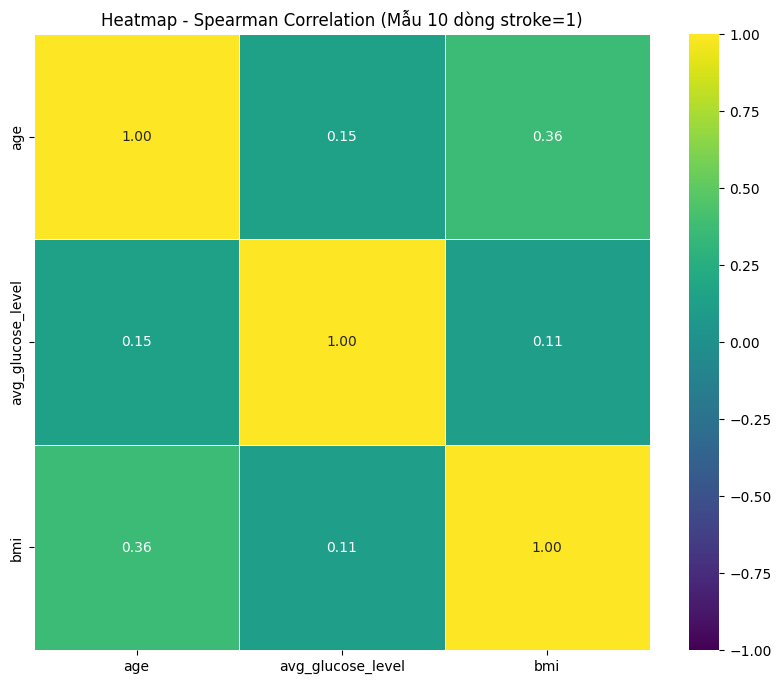

In [ ]:
# Spearman
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(method='spearman'),
            annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Heatmap - Spearman Correlation (Mẫu 10 dòng stroke=1)')
plt.show()

Tương tự nhưng đo tương quan hạng (rank-based), phù hợp hơn khi dữ liệu lệch/không tuyến tính — dùng để đối chiếu xem có quan hệ phi tuyến nào mà Pearson bỏ sót không.

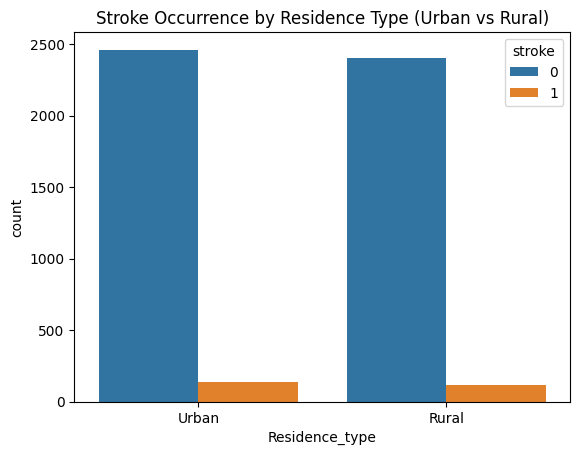

In [ ]:
sns.countplot(data=df, x='Residence_type', hue='stroke')
plt.title('Stroke Occurrence by Residence Type (Urban vs Rural)')
plt.show()

So sánh số ca stroke (0 vs 1) giữa dân cư Urban và Rural. Cho thấy tỷ lệ stroke ở hai nhóm khá tương đồng, gợi ý Residence_type có thể không phải yếu tố phân biệt mạnh.

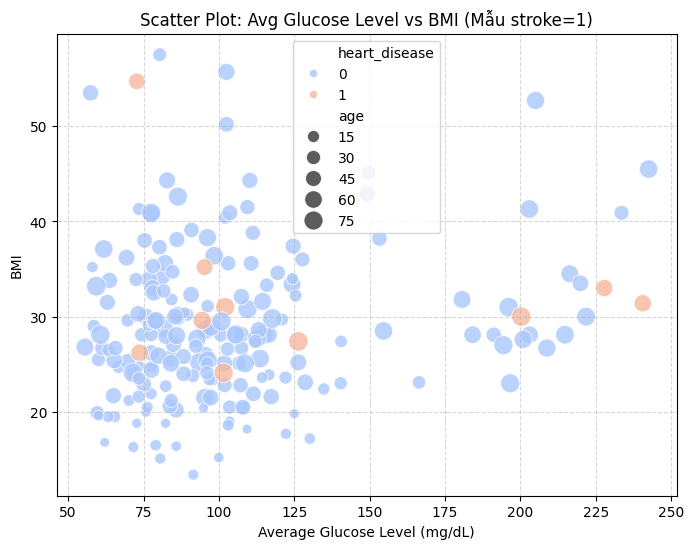

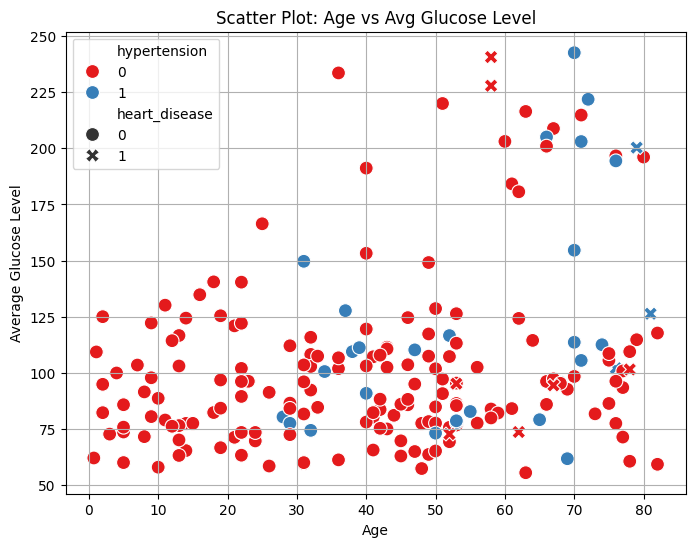

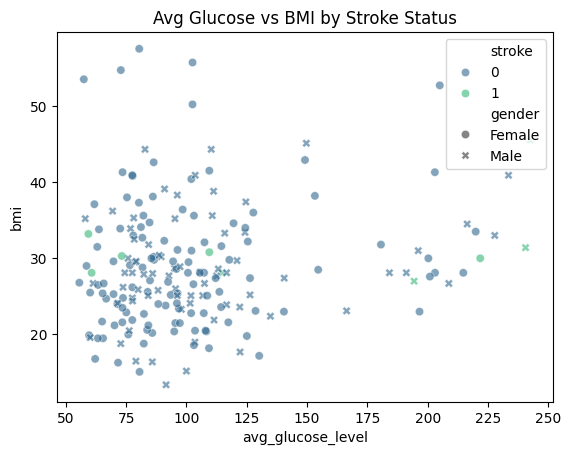

In [ ]:
df2 = df.sample(200)
# Scatter plot 1: avg_glucose_level vs bmi (tương quan mạnh nhất)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x='avg_glucose_level', y='bmi',
                hue='heart_disease', size='age', palette='coolwarm',
                sizes=(50, 200), alpha=0.8)
plt.title('Scatter Plot: Avg Glucose Level vs BMI (Mẫu stroke=1)')
plt.xlabel('Average Glucose Level (mg/dL)')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Scatter plot 2: age vs avg_glucose_level (thêm hue bằng hypertension)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x='age', y='avg_glucose_level',
                hue='hypertension', style='heart_disease',
                palette='Set1', s=100)
plt.title('Scatter Plot: Age vs Avg Glucose Level')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.grid(True)
plt.show()

# Scatter plot 3: avg_glucose_level vs bmi
sns.scatterplot(data=df2, x='avg_glucose_level', y='bmi', hue='stroke',
                style='gender', alpha=0.6, palette='viridis')
plt.title('Avg Glucose vs BMI by Stroke Status')
plt.show()

Biểu đồ phân tán giữa avg_glucose_level và bmi (và các cặp biến khác), tô màu theo heart_disease/stroke. Dùng để quan sát trực quan xem các ca stroke có tập trung ở vùng glucose/BMI cao hay không — thường không thấy ranh giới tách biệt rõ ràng, cho thấy quan hệ giữa các biến này với stroke không đơn giản/tuyến tính.

## **III. Model**

Đây là hàm tiện ích dùng chung cho mọi model sau này. Nó nhận vào model đã train, tính prediction theo một threshold tùy chỉnh (không phải mặc định 0.5), rồi in ra: bảng metrics (Accuracy, Precision, Recall, F1, ROC AUC) cho cả train & test, classification report, confusion matrix (train + test), ROC curve, và Precision-Recall vs Threshold curve. Viết hàm này một lần để tránh lặp code ở các model sau.

In [ ]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hàm evaluate (cập nhật: thêm classification_report + threshold tuning)
def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):
    # Predict với threshold tùy chỉnh
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    y_train_pred = (y_train_proba >= threshold).astype(int)
    y_test_pred  = (y_test_proba  >= threshold).astype(int)

    # Metrics
    metrics = {
        'Train': {
            'Accuracy': accuracy_score(y_train, y_train_pred),
            'Precision': precision_score(y_train, y_train_pred, zero_division=0),
            'Recall': recall_score(y_train, y_train_pred, zero_division=0),
            'F1': f1_score(y_train, y_train_pred, zero_division=0),
            'ROC AUC': roc_auc_score(y_train, y_train_proba)
        },
        'Test': {
            'Accuracy': accuracy_score(y_test, y_test_pred),
            'Precision': precision_score(y_test, y_test_pred, zero_division=0),
            'Recall': recall_score(y_test, y_test_pred, zero_division=0),
            'F1': f1_score(y_test, y_test_pred, zero_division=0),
            'ROC AUC': roc_auc_score(y_test, y_test_proba)
        }
    }

    print(f"\n=== Metrics (threshold = {threshold}) ===")
    print(pd.DataFrame(metrics).round(4))

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title('Train Confusion Matrix')
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes[1], cmap='Blues')
    axes[1].set_title('Test Confusion Matrix')
    plt.show()

    # ROC Curve
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_train, y_train, ax=ax, name='Train')
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name='Test')
    ax.plot([0,1], [0,1], 'k--')
    ax.set_title('ROC Curve')
    plt.show()

    # Precision-Recall Curve (giúp chọn threshold)
    prec, rec, thresh = precision_recall_curve(y_test, y_test_proba)
    plt.figure(figsize=(8, 5))
    plt.plot(thresh, prec[:-1], label='Precision')
    plt.plot(thresh, rec[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision-Recall vs Threshold (Test set)')
    plt.legend()
    plt.grid()
    plt.show()


Điền nốt bmi còn thiếu bằng median (dòng df.drop('id') bị comment nên cột id vẫn còn trong X — cần lưu ý vì id không có ý nghĩa dự đoán). Tách X (features) và y (stroke), chia train/test 80/20 với stratify=y để giữ tỷ lệ mất cân bằng đồng đều giữa 2 tập. Đồng thời khai báo danh sách 3 nhóm cột: numerical, categorical, binary.

In [ ]:
# Preprocess
#df.drop('id', axis=1, inplace=True)
# bmi NaN → median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

X = df.drop('stroke', axis=1)
y = df['stroke']

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Columns
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_cols = ['hypertension', 'heart_disease']


Dùng ColumnTransformer để xử lý riêng từng nhóm cột: cột số → impute median + StandardScaler; cột phân loại → OneHotEncoder (bỏ 1 cột để tránh đa cộng tuyến); cột nhị phân (hypertension, heart_disease) → giữ nguyên (passthrough). Đây là bước tiền xử lý dùng chung cho mọi model bên dưới.

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

Xây pipeline: preprocessor → SMOTE (cân bằng lớp thiểu số stroke) → Logistic Regression. Dùng GridSearchCV (dò toàn bộ lưới tham số) tối ưu theo roc_auc, tìm C, penalty, tham số SMOTE tốt nhất. Sau đó gọi evaluate_model với threshold=0.65 (thay vì 0.5 mặc định) để cân bằng lại precision/recall.

Đang thực hiện GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'smote__k_neighbors': 7, 'smote__sampling_strategy': 0.3}

Best ROC AUC (trên CV): 0.8415

Thử các threshold khác để tối ưu:

=== Metrics (threshold = 0.65) ===
            Train    Test
Accuracy   0.8143  0.8297
Precision  0.1577  0.1837
Recall     0.6482  0.7200
F1         0.2537  0.2927
ROC AUC    0.8409  0.8397

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.84      0.90       972
           1       0.18      0.72      0.29        50

    accuracy                           0.83      1022
   macro avg       0.58      0.78      0.60      1022
weighted avg       0.94      0.83      0.87      1022



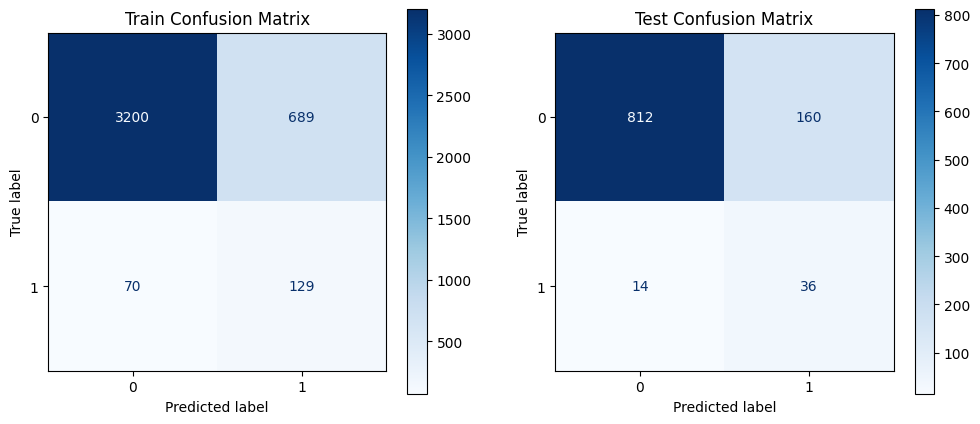

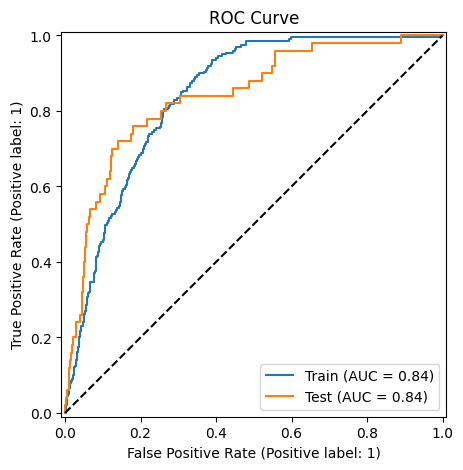

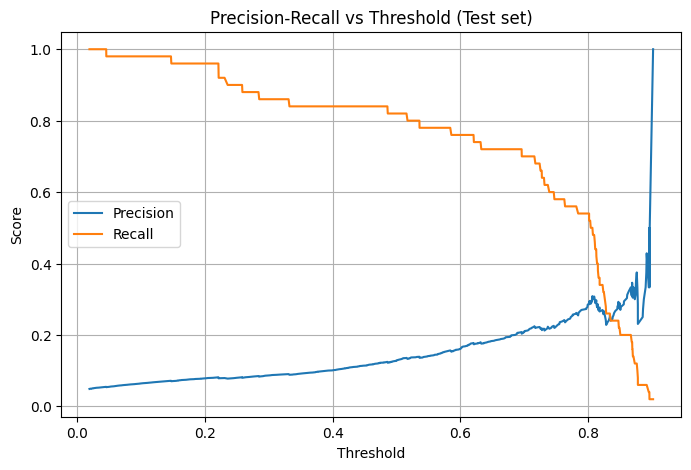

In [ ]:
# Pipeline với SMOTE + LR
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,          # Tăng để đảm bảo hội tụ khi C nhỏ
        random_state=42
    ))
])

# Param grid – tập trung tuning quan trọng, không quá rộng để tiết kiệm thời gian
param_grid = {
    'smote__sampling_strategy': [0.3],          # Tỷ lệ minority/majority sau oversample
    'smote__k_neighbors': [3, 5, 7],                      # Số neighbor cho SMOTE
    'classifier__C': [0.01, 0.05, 0.1],    # Regularization strength
    'classifier__penalty': ['l1', 'l2']                   # L1 hoặc L2
}

# GridSearchCV
print("Đang thực hiện GridSearchCV...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                      # 5-fold cross-validation
    scoring='roc_auc',         # Tốt nhất cho imbalance (hoặc 'f1' nếu ưu tiên F1)
    n_jobs=-1,                 # Dùng tất cả core
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Kết quả tuning
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest ROC AUC (trên CV): {:.4f}".format(grid_search.best_score_))

# Model tốt nhất
best_model = grid_search.best_estimator_

# Thử tuning threshold
print("\nThử các threshold khác để tối ưu:")
evaluate_model(best_model, X_train, y_train, X_test, y_test, threshold=0.65)

Tương tự nhưng đổi classifier thành Random Forest, và dùng RandomizedSearchCV (dò ngẫu nhiên một tập con tham số) thay vì Grid — nhanh hơn vì RF có nhiều tham số hơn. Đánh giá test set 2 lần: một lần thủ công (threshold mặc định 0.5) rồi một lần qua evaluate_model (threshold 0.65).

Đang tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:
{'smote__sampling_strategy': 0.5, 'classifier__n_estimators': 500, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced_subsample'}
Best ROC AUC (CV): 0.8132

=== Test Set Performance ===
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       972
           1       0.12      0.82      0.21        50

    accuracy                           0.69      1022
   macro avg       0.55      0.75      0.51      1022
weighted avg       0.94      0.69      0.78      1022

ROC AUC: 0.8269

=== Metrics (threshold = 0.65) ===
            Train    Test
Accuracy   0.8929  0.8875
Precision  0.2385  0.1963
Recall     0.5477  0.4200
F1         0.3323  0.2675
ROC AUC    0.8850  0.8269

Classification Report (Test):
              precis

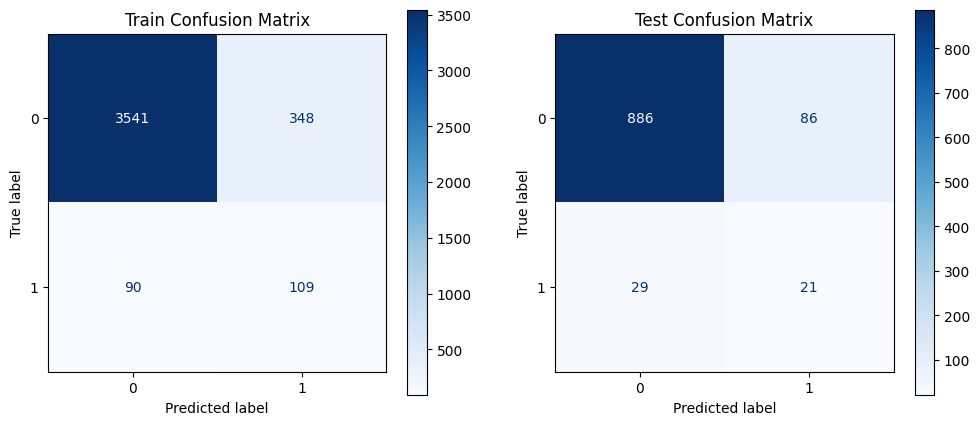

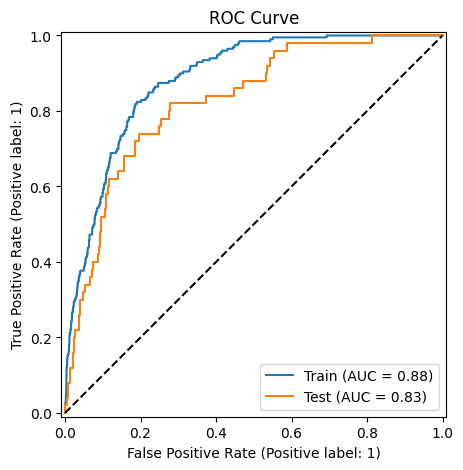

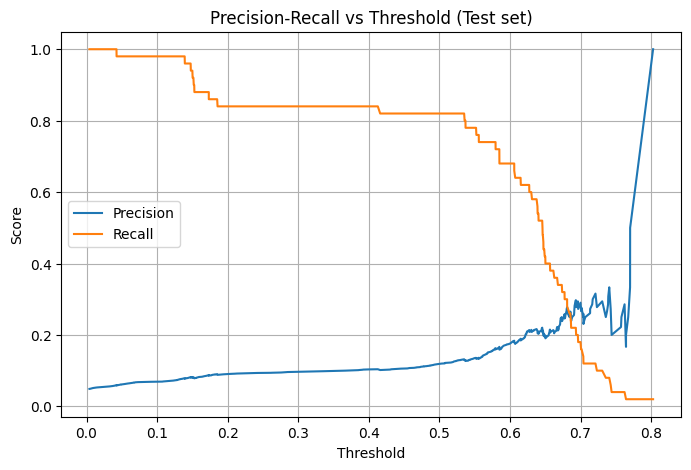

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# Pipeline với Random Forest
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),                  # từ code cũ của bạn
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Tham số tuning (RandomizedSearchCV nhanh hơn Grid cho RF)
param_dist = {
    'smote__sampling_strategy': [0.5, 0.8],
    'classifier__n_estimators': [500],
    'classifier__max_depth': [5, 8],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [4, 6],
    'classifier__max_features': ['sqrt'],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

# Randomized search (n_iter=30 để tiết kiệm thời gian)
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Đang tuning Random Forest...")
random_search.fit(X_train, y_train)

# Kết quả
print("\nBest params:")
print(random_search.best_params_)
print(f"Best ROC AUC (CV): {random_search.best_score_:.4f}")

# Model tốt nhất
best_rf = random_search.best_estimator_

# Đánh giá trên test
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Test Set Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

evaluate_model(best_rf, X_train, y_train, X_test, y_test, threshold=0.65)

Pipeline SVM với kernel RBF/poly, probability=True để lấy được xác suất (cần cho ROC AUC). Tune các tham số đặc trưng của SVM (C, gamma, degree, kernel). Có đoạn code comment sẵn để thử nhiều threshold khác nhau (0.3–0.55) — chưa chạy, chỉ để tham khảo.

Đang tuning SVM (có thể mất 3–10 phút tùy máy)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best parameters:
{'smote__sampling_strategy': 0.6, 'classifier__kernel': 'rbf', 'classifier__gamma': 0.001, 'classifier__degree': 3, 'classifier__C': 1.0}
Best ROC AUC (CV): 0.8408

=== SVM Test Set Performance ===
              precision    recall  f1-score   support

           0       0.99      0.69      0.82       972
           1       0.12      0.84      0.22        50

    accuracy                           0.70      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.70      0.79      1022

ROC AUC: 0.8415

=== Metrics (threshold = 0.65) ===
            Train    Test
Accuracy   0.8630  0.8787
Precision  0.1850  0.2279
Recall     0.5327  0.6200
F1         0.2746  0.3333
ROC AUC    0.8449  0.8415

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       9

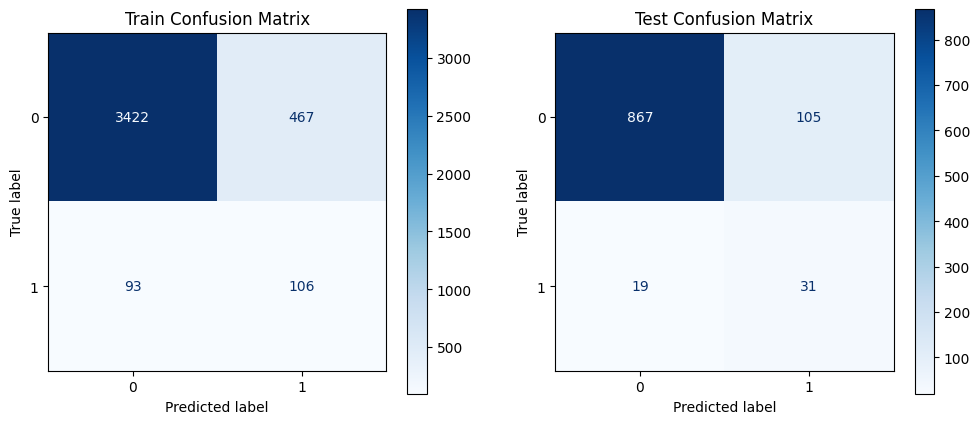

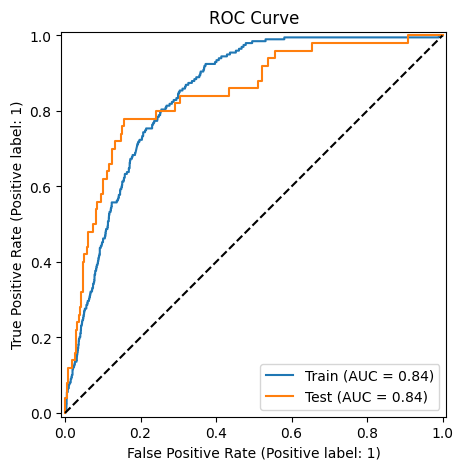

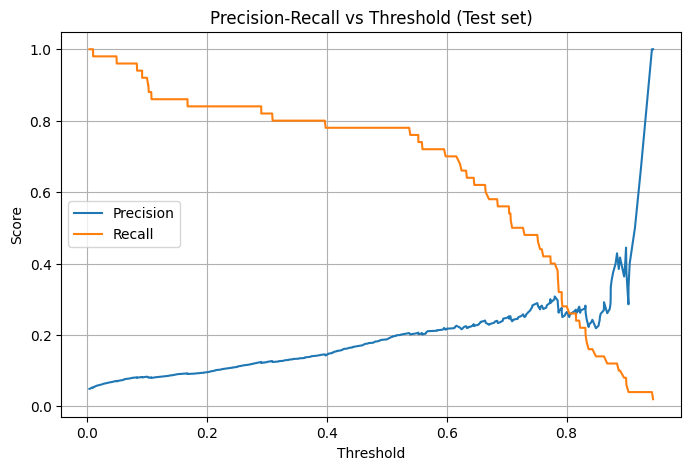

In [ ]:
from sklearn.svm import SVC

# Pipeline cho SVM
svm_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),  # từ code cũ: scale num + encode cat + passthrough binary
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(
        probability=True,          # cần để có predict_proba → ROC AUC
        random_state=42,
        class_weight='balanced'
    ))
])

# Tham số tuning (RandomizedSearchCV vì SVM khá tốn thời gian)
param_dist = {
    'smote__sampling_strategy': [0.4, 0.6],
    'classifier__kernel': ['rbf', 'poly'],           # RBF thường tốt nhất cho dataset này
    'classifier__C': [0.1, 0.5, 1.0],         # regularization (ngược với LR)
    'classifier__gamma': ['scale',0.001, 0.01, 0.1],  # chỉ dùng khi kernel = rbf/poly
    'classifier__degree': [2, 3, 4]                            # chỉ dùng khi kernel = poly
}

# Randomized search (n_iter nhỏ vì SVM chậm trên dataset ~5000 dòng)
random_search_svm = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_dist,
    n_iter=25,                # điều chỉnh nếu máy mạnh thì tăng lên 40–50
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Đang tuning SVM (có thể mất 3–10 phút tùy máy)...")
random_search_svm.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:")
print(random_search_svm.best_params_)
print(f"Best ROC AUC (CV): {random_search_svm.best_score_:.4f}")

# Model tốt nhất
best_svm = random_search_svm.best_estimator_

# Đánh giá trên test set
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

print("\n=== SVM Test Set Performance ===")
print(classification_report(y_test, y_pred_svm))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_svm):.4f}")

# Nếu bạn có hàm evaluate_model từ trước, gọi luôn:
evaluate_model(best_svm, X_train, y_train, X_test, y_test, threshold=0.65)

# Thử một số threshold khác (SVM thường cho probability khá "cực đoan")
#for th in [0.3, 0.4, 0.45, 0.5, 0.55]:
#    print(f"\nThreshold = {th}")
#    y_pred_th = (y_proba_svm >= th).astype(int)
#    print(classification_report(y_test, y_pred_th))

Pipeline K-Nearest Neighbors, tune n_neighbors, weights, metric, p. Đánh giá với threshold=0.5 (thấp hơn các model khác vì tác giả ghi chú KNN "thường nên thấp hơn RF").

Đang tuning KNN...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best params:
{'smote__sampling_strategy': 0.7, 'classifier__weights': 'uniform', 'classifier__p': 2, 'classifier__n_neighbors': 27, 'classifier__metric': 'euclidean'}
Best ROC AUC (CV): 0.7732

=== Test Set Performance (KNN) ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       972
           1       0.12      0.68      0.21        50

    accuracy                           0.75      1022
   macro avg       0.55      0.72      0.53      1022
weighted avg       0.94      0.75      0.82      1022

ROC AUC: 0.7807

=== Metrics (threshold = 0.5) ===
            Train    Test
Accuracy   0.7664  0.7476
Precision  0.1661  0.1232
Recall     0.9447  0.6800
F1         0.2825  0.2086
ROC AUC    0.9346  0.7807

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       972
           1   

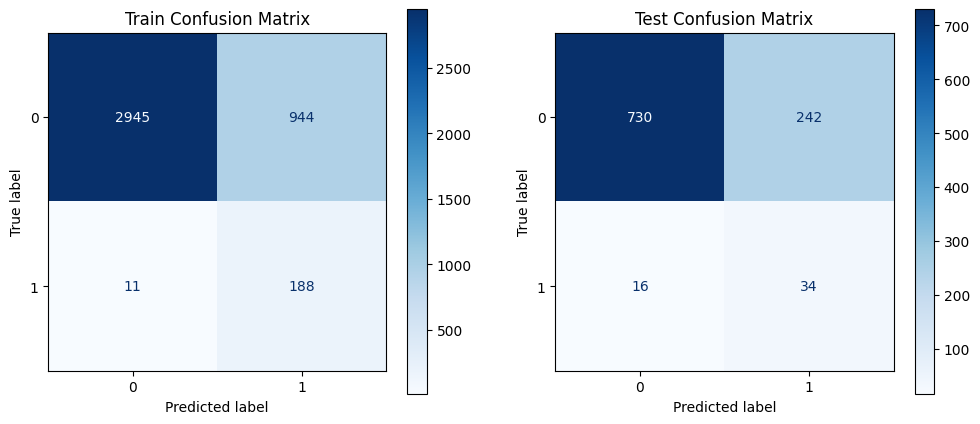

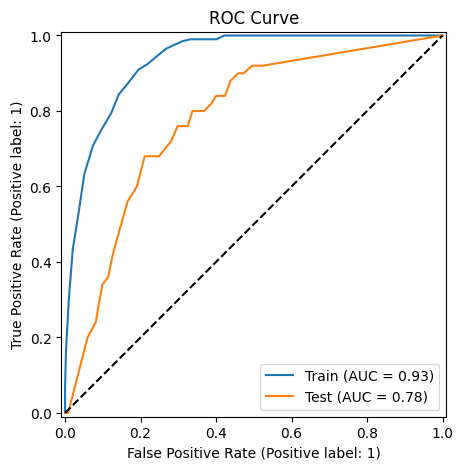

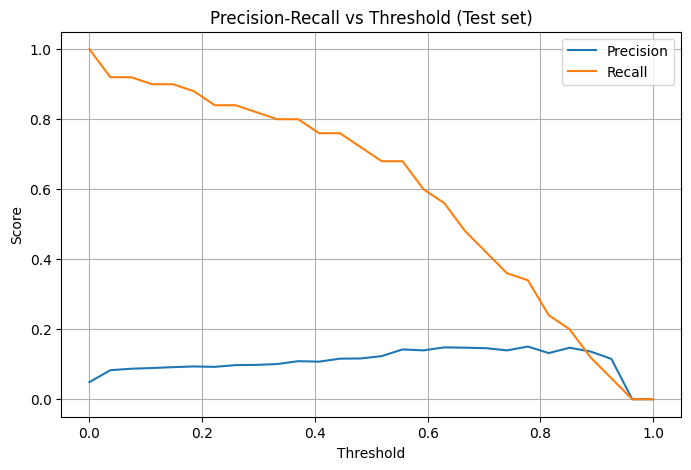

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline với KNN
knn_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),   # phải có scaler bên trong
    ('smote', SMOTE(random_state=42)),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        metric='minkowski',
        p=2,              # Euclidean
        algorithm='auto',
        leaf_size=30)
)
])

# Tham số tuning cho KNN
param_dist = {
    'smote__sampling_strategy': [0.5, 0.7, 1],
    'classifier__n_neighbors': [20, 24, 27],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan'],
    'classifier__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_dist,
    n_iter=25,            # KNN nhanh, không cần quá nhiều
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Đang tuning KNN...")
random_search.fit(X_train, y_train)

# Kết quả tuning
print("\nBest params:")
print(random_search.best_params_)
print(f"Best ROC AUC (CV): {random_search.best_score_:.4f}")

# Model tốt nhất
best_knn = random_search.best_estimator_

y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

print("\n=== Test Set Performance (KNN) ===")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

evaluate_model(
    best_knn,
    X_train, y_train,
    X_test, y_test,
    threshold=0.5   # KNN thường nên thấp hơn RF
)


Pipeline Gradient Boosting (XGBoost), tune các tham số boosting đặc trưng (n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma). Đánh giá với threshold=0.35 (thấp hơn hẳn) vì XGBoost cho ra xác suất khá "tự tin" nên cần threshold thấp hơn để bắt được nhiều ca stroke hơn.

Đang tuning XGBoost (có thể mất một thời gian)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
{'smote__sampling_strategy': 0.4, 'classifier__subsample': 0.6, 'classifier__n_estimators': 400, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.02, 'classifier__colsample_bytree': 0.4}
Best ROC AUC (CV): 0.8206

=== XGBoost Test Set Performance ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.40      0.08      0.13        50

    accuracy                           0.95      1022
   macro avg       0.68      0.54      0.55      1022
weighted avg       0.93      0.95      0.93      1022

ROC AUC: 0.8109

=== Metrics (threshold = 0.35) ===
            Train    Test
Accuracy   0.9440  0.9149
Precision  0.4472  0.2063
Recall     0.6382  0.2600
F1         0.5259  0.2301
ROC AUC    0.9412  0.8109

Classification Report (Test):
              pr

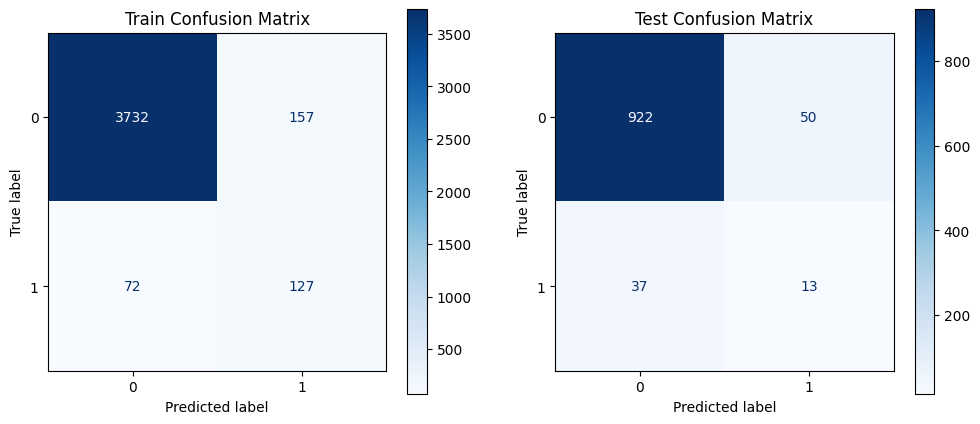

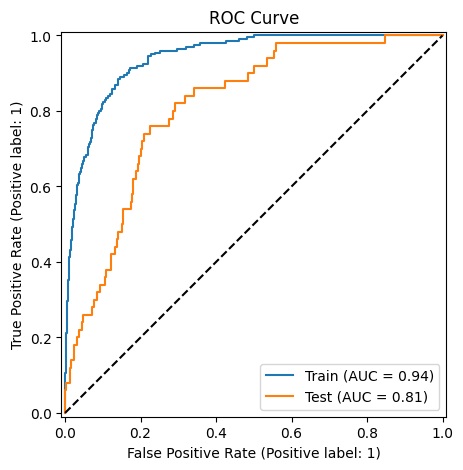

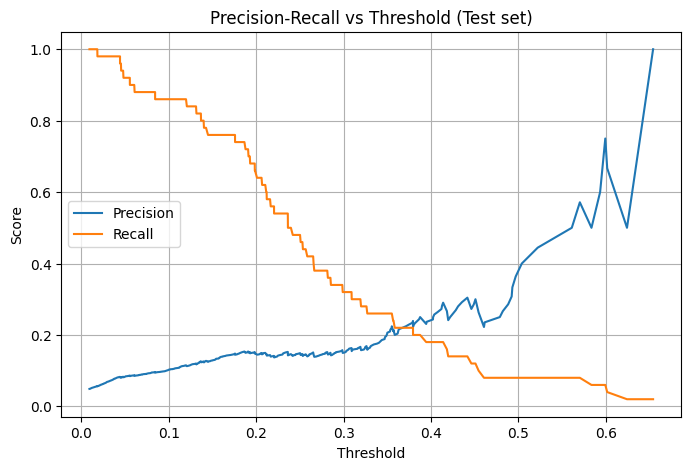

In [ ]:
from xgboost import XGBClassifier

# Pipeline cho XGBoost
xgboost_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),  # scale num + encode cat + passthrough binary
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False # Suppress warning
    ))
])

# Tham số tuning cho XGBoost (RandomizedSearchCV)
param_dist = {
    'smote__sampling_strategy': [0.4, 0.6, 0.8],
    'classifier__n_estimators': [300, 400],
    'classifier__max_depth': [5, 7],
    'classifier__learning_rate': [0.01, 0.02],
    'classifier__subsample': [0.6, 0.8],
    'classifier__colsample_bytree': [0.4, 0.6],
    'classifier__gamma': [0.01, 0.02]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(
    xgboost_pipeline,
    param_distributions=param_dist,
    n_iter=50,                # Tăng n_iter nếu có thời gian
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Đang tuning XGBoost (có thể mất một thời gian)...")
random_search_xgb.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:")
print(random_search_xgb.best_params_)
print(f"Best ROC AUC (CV): {random_search_xgb.best_score_:.4f}")

# Model tốt nhất
best_xgboost = random_search_xgb.best_estimator_

# Đánh giá trên test set
y_pred_xgb = best_xgboost.predict(X_test)
y_proba_xgb = best_xgboost.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Test Set Performance ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Sử dụng hàm evaluate_model đã định nghĩa
evaluate_model(
    best_xgboost,
    X_train, y_train,
    X_test, y_test,
    threshold=0.35 # Có thể điều chỉnh threshold này dựa trên biểu đồ Precision-Recall
)

Tương tự XGBoost nhưng dùng LightGBM, tune bộ tham số riêng (num_leaves, min_child_samples, reg_alpha, reg_lambda...). Cũng dùng threshold=0.35 khi đánh giá cuối.

Đang tuning LightGBM (có thể mất một thờngian)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 3111, number of negative: 3889
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3143
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444429 -> initscore=-0.223208
[LightGBM] [Info] Start training from score -0.223208
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Best parameters:
{'smote__sampling_strategy': 0.8, 'classifier__subsample': 0.8, 'classifier__re

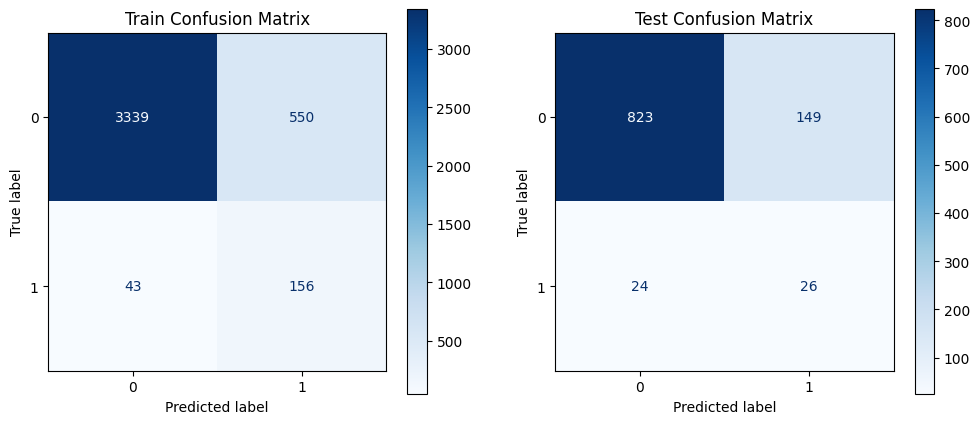

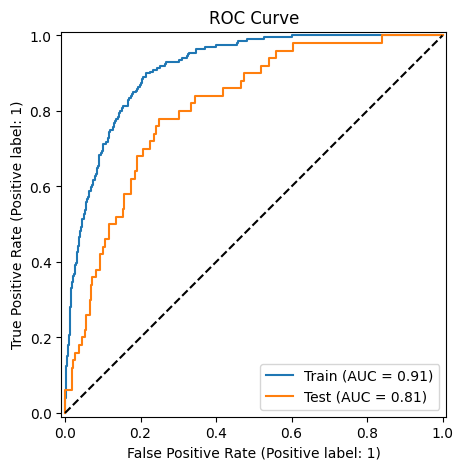

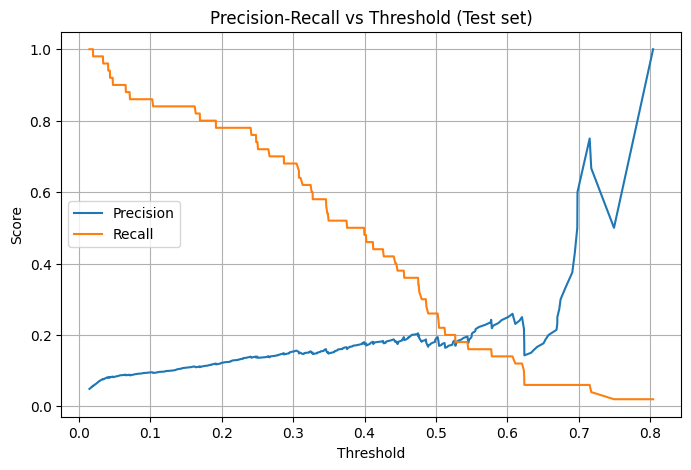

In [ ]:
from lightgbm import LGBMClassifier

# Pipeline cho LightGBM
lgbm_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),  # scale num + encode cat + passthrough binary
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        objective='binary' # Cho bài toán phân loại nhị phân
    ))
])

# Tham số tuning cho LightGBM (RandomizedSearchCV)
param_dist = {
    'smote__sampling_strategy': [0.6, 0.8],
    'classifier__n_estimators': [200, 500],
    'classifier__max_depth': [5, 8],
    'classifier__learning_rate': [0.01, 0.02],
    'classifier__num_leaves': [20, 31],
    'classifier__min_child_samples': [50, 70],
    'classifier__subsample': [0.6, 0.8],
    'classifier__colsample_bytree': [0.6, 0.8],
    'classifier__reg_alpha': [0.5, 1.0, 2.0],
    'classifier__reg_lambda': [0.5, 1.0, 2.0],
}

# Randomized search
random_search_lgbm = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=param_dist,
    n_iter=50,                # Tăng n_iter nếu có thời gian
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Đang tuning LightGBM (có thể mất một thờngian)...")
random_search_lgbm.fit(X_train, y_train)

# Kết quả
print("\nBest parameters:")
print(random_search_lgbm.best_params_)
print(f"Best ROC AUC (CV): {random_search_lgbm.best_score_:.4f}")

# Model tốt nhất
best_lgbm = random_search_lgbm.best_estimator_

# Đánh giá trên test set
y_pred_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

print("\n=== LightGBM Test Set Performance ===")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")

# Sử dụng hàm evaluate_model đã định nghĩa
evaluate_model(
    best_lgbm,
    X_train, y_train,
    X_test, y_test,
    threshold=0.35 # Có thể điều chỉnh threshold này dựa trên biểu đồ Precision-Recall
)

## **4. Đánh giá & So sánh các Mô hình**

### 1. Bối cảnh
Xây dựng pipeline dự đoán **stroke** (nhãn nhị phân, mất cân bằng nặng: ~5% dương tính) với các bước:
- **Tiền xử lý**: `ColumnTransformer` (chuẩn hóa numeric bằng `StandardScaler`, encode categorical, giữ nguyên biến nhị phân).
- **Cân bằng dữ liệu**: `SMOTE` được nhúng trong `ImbPipeline` để chỉ oversample trên tập train của mỗi fold, tránh leakage giữa train/test.
- **Tối ưu tham số**: `GridSearchCV` (Logistic Regression) và `RandomizedSearchCV` (Random Forest, SVM, KNN, XGBoost, LightGBM), scoring = `roc_auc`, cv = 5.
- **Đánh giá**: mỗi mô hình được thử nhiều `threshold` phân loại khác nhau (thay vì mặc định 0.5) để cân bằng giữa Precision và Recall — điều cần thiết vì bài toán y tế ưu tiên phát hiện đúng ca dương tính (Recall) hơn là độ chính xác tổng thể.

---

### 2. Bảng kết quả tổng hợp (Test set, sau khi chọn threshold tối ưu)

| Model | Threshold | CV ROC AUC | Test ROC AUC | Accuracy | Precision (stroke=1) | Recall (stroke=1) | F1 (stroke=1) |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.65 | 0.8415 | 0.8397 | 0.8297 | 0.1837 | **0.7200** | 0.2927 |
| Random Forest | 0.65 | 0.8132 | 0.8269 | 0.8875 | 0.1963 | 0.4200 | 0.2675 |
| SVM (RBF) | 0.65 | 0.8408 | **0.8415** | 0.8787 | 0.2279 | 0.6200 | **0.3333** |
| KNN | 0.50 | 0.7732 | 0.7807 | 0.7476 | 0.1232 | 0.6800 | 0.2086 |
| XGBoost | 0.35 | 0.8206 | 0.8109 | **0.9149** | 0.2063 | 0.2600 | 0.2301 |
| LightGBM | 0.35 | 0.8218 | 0.8105 | 0.8307 | 0.1486 | 0.5200 | 0.2311 |

> **Ghi chú**: In đậm = giá trị tốt nhất theo cột.

---

### 3. Đánh giá từng mô hình

**Logistic Regression** — Baseline tuyến tính nhưng cho ROC AUC cao gần nhất bảng (0.8397) và **Recall cao nhất (0.72)**, tức bắt được phần lớn ca stroke thật, đánh đổi bằng Precision thấp (nhiều false positive). Đây là lựa chọn hợp lý nếu mục tiêu là *sàng lọc* (không bỏ sót bệnh nhân nguy cơ).

**Random Forest** — ROC AUC CV thấp nhất trong nhóm cây quyết định (0.8132), Recall chỉ 0.42 dù đã cân bằng bằng SMOTE — cho thấy mô hình vẫn thiên về lớp đa số. Accuracy cao (0.8875) nhưng ít ý nghĩa với bài toán mất cân bằng.

**SVM (RBF kernel)** — Cân bằng tốt nhất giữa Precision và Recall, đạt **F1 và ROC AUC test cao nhất** trong cả 6 model. Là ứng viên tổng thể mạnh nhất nếu cần một mô hình duy nhất.

**KNN** — ROC AUC thấp nhất (0.78), phản ánh KNN không xử lý tốt dữ liệu nhiều chiều/categorical sau one-hot encode. Không nên chọn.

**XGBoost** — Accuracy cao nhất (0.9149) nhưng **Recall rất thấp (0.26)** — mô hình gần như bỏ sót 3/4 số ca stroke thật. Đây là dấu hiệu rõ của việc overfitting vào lớp đa số dù threshold đã hạ xuống 0.35. Không phù hợp cho bài toán y tế cần recall cao.

**LightGBM** — Tương tự XGBoost nhưng recall khá hơn (0.52), tuy nhiên ROC AUC test thấp nhất trong nhóm boosting (0.8105). Log cảnh báo `No further splits with positive gain` cho thấy một số cây con không học được gì thêm — có thể do `min_child_samples` quá cao so với kích thước tập train sau SMOTE.

**Kết luận**: Nếu ưu tiên phát hiện đúng ca dương tính (Recall) → chọn **Logistic Regression** hoặc **SVM**. Nếu cần mô hình cân bằng tổng thể tốt nhất theo ROC AUC/F1 → **SVM** là lựa chọn tối ưu trong 6 mô hình đã thử.

---

### 4. Đánh giá các hình ảnh minh họa

Mỗi model xuất ra 3 hình từ hàm `evaluate_model`:

1. **Biểu đồ 4-panel (Train vs Test)** — so sánh Accuracy, Precision, Recall, F1, ROC AUC giữa train và test. Dùng để phát hiện overfitting: khoảng cách lớn giữa 2 cột train/test (rõ nhất ở XGBoost và LightGBM, ví dụ train ROC AUC ~0.91–0.94 nhưng test chỉ ~0.81) cho thấy các mô hình boosting bị overfit khá nhiều dù đã regularize (`reg_alpha`, `reg_lambda`).
2. **Confusion Matrix** — trực quan hóa số lượng true/false positive/negative. Với XGBoost, ma trận sẽ cho thấy rất ít true positive (recall thấp) minh chứng cho nhận định ở trên.
3. **ROC Curve** — thể hiện trade-off giữa TPR và FPR ở mọi threshold. Đường cong của SVM và Logistic Regression sát góc trên-trái nhất, phù hợp với ROC AUC cao đo được.

**Các hình EDA trước đó** cũng hỗ trợ diễn giải kết quả model:
- Heatmap tương quan (cell 16–17) cho thấy `age` có tương quan dương rõ nhất với `stroke`, giải thích vì sao các mô hình tuyến tính đơn giản (Logistic Regression) vẫn hoạt động tốt.
- Biểu đồ outlier (cell 11) cho thấy `avg_glucose_level` có nhiều outlier (627 điểm) — đây có thể là lý do các mô hình dựa trên khoảng cách (KNN, SVM) nhạy cảm với scaling, và việc dùng `StandardScaler` trong pipeline là cần thiết.
- Countplot theo Residence_type (cell 18) cho thấy tỷ lệ stroke giữa Urban/Rural khá tương đồng, gợi ý biến này có sức mạnh dự đoán yếu — phù hợp với việc các mô hình cây (Random Forest, XGBoost) không cải thiện đáng kể so với Logistic Regression dù xử lý phi tuyến tốt hơn.

## **V. Kết luận**

## 🔚 Kết luận

### Tóm tắt quá trình
Notebook đã xây dựng và so sánh 6 mô hình phân loại (Logistic Regression, Random Forest, SVM, KNN, XGBoost, LightGBM) để dự đoán nguy cơ đột quỵ (stroke) trên bộ dữ liệu 5110 bệnh nhân, với đặc điểm nổi bật là **mất cân bằng nhãn nghiêm trọng** (~5% dương tính). Mỗi mô hình đều được tối ưu hyperparameter bằng Grid/RandomizedSearchCV (scoring = ROC AUC, cv=5), kết hợp SMOTE để cân bằng dữ liệu và tinh chỉnh threshold phân loại nhằm tối ưu Recall — chỉ số quan trọng nhất trong bài toán y tế, nơi bỏ sót một ca dương tính (false negative) nguy hiểm hơn nhiều so với một cảnh báo nhầm (false positive).

### Mô hình được đề xuất
- **SVM (RBF kernel)** đạt kết quả cân bằng tốt nhất: ROC AUC test cao nhất (0.8415) và F1-score cao nhất (0.3333) trong 6 mô hình, là lựa chọn tổng thể hợp lý nếu cần một mô hình duy nhất triển khai.
- **Logistic Regression** là lựa chọn thay thế đáng cân nhắc nếu ưu tiên tuyệt đối vào **Recall** (0.72) — tức khả năng phát hiện đúng ca có nguy cơ đột quỵ cao nhất trong tất cả các mô hình, phù hợp với mục tiêu sàng lọc y tế (không bỏ sót bệnh nhân nguy cơ).
- Các mô hình boosting (**XGBoost**, **LightGBM**) tuy có Accuracy cao nhất nhưng Recall thấp (0.26 và 0.52) — không phù hợp cho bài toán này dù về mặt lý thuyết là mô hình mạnh hơn, cho thấy **accuracy là chỉ số gây hiểu lầm** trên dữ liệu mất cân bằng.

### Hạn chế
- **Nguy cơ rò rỉ dữ liệu (data leakage) nhẹ**: giá trị thiếu của `bmi` được điền bằng median tính trên toàn bộ dataset (trước khi chia train/test) ở cell 21, thay vì chỉ fit trên tập train. Cần khắc phục để đảm bảo đánh giá không bị lạc quan quá mức.
- **Overfitting ở nhóm mô hình cây/boosting**: khoảng cách ROC AUC giữa train và test khá lớn (ví dụ XGBoost: train ~0.94 vs test ~0.81), dù đã áp dụng regularization (`reg_alpha`, `reg_lambda`) và giới hạn độ sâu cây.
- **Precision còn thấp ở mọi mô hình** (0.12–0.23): số lượng false positive còn nhiều, có thể gây quá tải cho hệ thống sàng lọc thực tế nếu triển khai trực tiếp.
- **Cỡ mẫu dương tính nhỏ** (chỉ ~250 ca stroke trong toàn bộ dataset) khiến kết quả đánh giá trên test set (50 ca dương tính) có phương sai cao, cần thẩm định thêm qua cross-validation nhiều lần hoặc tập dữ liệu độc lập lớn hơn.

### Hướng cải thiện tiếp theo
1. Sửa lỗi leakage: đưa bước impute `bmi` vào trong pipeline (đã có `SimpleImputer` trong `ColumnTransformer`, nên bỏ bước fillna thủ công ở cell 21).
2. Thử kết hợp nhiều mô hình (ensemble/stacking) giữa Logistic Regression và SVM để tận dụng ưu điểm Recall cao và ROC AUC cao.
3. Thử các kỹ thuật xử lý mất cân bằng khác ngoài SMOTE (ví dụ: class weighting kết hợp threshold tuning, hoặc cost-sensitive learning) để so sánh hiệu quả.
4. Đánh giá thêm bằng chỉ số **Precision-Recall AUC** thay vì chỉ ROC AUC, vì PR-AUC nhạy hơn với lớp thiểu số trong bài toán mất cân bằng mạnh như thế này.